In [14]:
import pandas as pd 
import numpy as np 

from sklearn.preprocessing import Normalizer, StandardScaler

import pickle as pk

import seaborn as sns
import matplotlib.pyplot as plt

# Data loading and pre-processing. 

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 

In [3]:
# Filter the data to the strong antigens, first repliate, OT-1 cells, high concentration, and later. 
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Concentration') == '1uM') & 
                       (data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 30.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]


In [8]:
# def norm(group): 
#     return pd.DataFrame(StandardScaler().fit_transform(group), columns=group.columns, index=group.index)

# normalized_df = df.groupby(['Time']).apply(norm)

normalized_df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index)

# Compute the Correlation of each Marker

In [10]:
corr = normalized_df.corr(method='pearson')

Text(0.5, 1.0, 'Pearson Correlation Matrix')

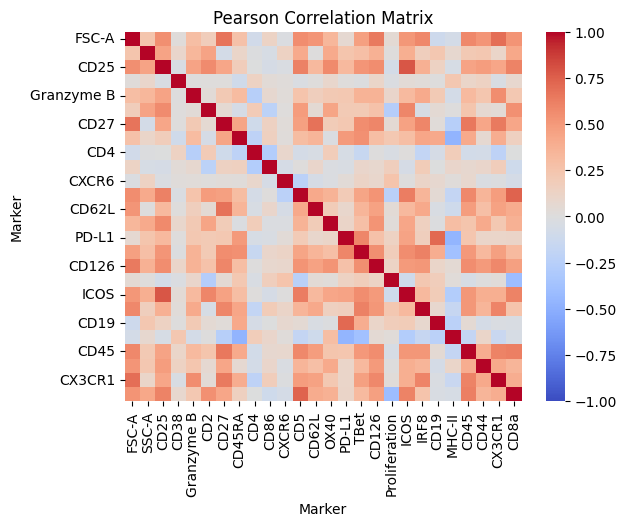

In [25]:
sns.heatmap(corr, annot=False, cmap='coolwarm', vmax=1.0, vmin=-1.0)
plt.title("Pearson Correlation Matrix")

The top ten markers found were: `SSC-A, CD25, Granzyme B, CD2, CD5, CD126, Proliferation, ICOS, IRF8, and CD8a`. 

There are a couple of markers that have a low correlation with everything else, and Proliferation is the only one that really stands out as one of these among the prviously identified top ten markers. 

In [26]:
IMPORTANT_MARKERS = ['SSC-A', 'CD25', 'Granzyme B', 'CD2', 'CD5', 'CD126', 'Proliferation', 'ICOS', 'IRF8', 'CD8a']

Text(0.5, 1.0, 'Pearson Correlation Matrix')

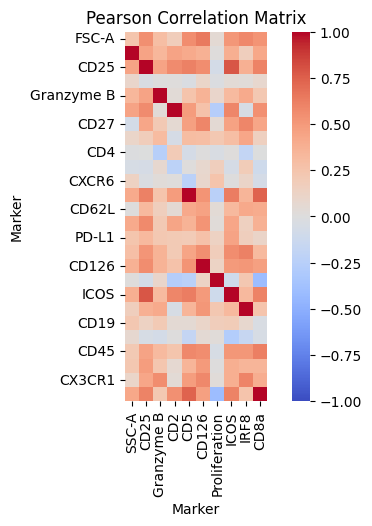

In [28]:
sns.heatmap(corr[IMPORTANT_MARKERS], annot=False, cmap='coolwarm', vmax=1.0, vmin=-1.0, square=True)
plt.title("Pearson Correlation Matrix")